<a href="https://colab.research.google.com/github/zackdihel/ECON-5200-Data-Analytics/blob/main/Assignment%204/Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
%matplotlib inline
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno
!pip install category_encoders

In [24]:
url_vitals = 'https://raw.githubusercontent.com/zackdihel/ECON-5200-Data-Analytics/refs/heads/main/Assignment%204/OmniCare_Clinical_Vitals.csv'
url_tele = 'https://raw.githubusercontent.com/zackdihel/ECON-5200-Data-Analytics/refs/heads/main/Assignment%204/OmniCare_Telemetry_Data.csv'

df_vitals = pd.read_csv(url_vitals)
df_tele = pd.read_csv(url_tele)

df_vitals.head()

,Patient_ID,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,177.5,66.3,21.06,110.0,75.0
1,1001,167.9,57.5,20.39,115.0,79.0
2,1002,179.7,57.4,17.77,111.0,77.0
3,1003,192.8,80.9,21.76,122.0,88.0
4,1004,166.5,65.7,23.70,138.0,89.0


In [25]:
df_tele.head()

,Patient_ID,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD
0,1000,1,0.341,76.9,J86.381,0.63,19.4,1635.84
1,1001,0,0.213,79.6,M29.789,0.71,19.3,1355.77
2,1002,0,0.166,92.3,E49.618,0.76,16.8,1189.19
3,1003,1,0.143,79.3,E66.244,0.52,11.5,1250.93
4,1004,0,0.219,75.9,J45.553,0.65,20.2,1986.34


In [26]:
model = smf.ols('Inpatient_Admission_Rate ~ High_Deductible_Insurance_Plan', data=df_tele).fit()
print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     Inpatient_Admission_Rate   R-squared:                       0.091
Model:                                  OLS   Adj. R-squared:                  0.091
Method:                       Least Squares   F-statistic:                     499.2
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):          1.77e-105
Time:                              16:02:29   Log-Likelihood:                 3560.0
No. Observations:                      5000   AIC:                            -7116.
Df Residuals:                          4998   BIC:                            -7103.
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

# Directed Acyclic Graph
The missing confounder in this simple regression is a measurement of socioeconomic status. This status is unobserved in the data but acts as a catalyst for both High Deductible Insurance Plans as well as Inpatient Admissions. Without controlling for socioeconomic status, the results are assuming that HDIP is causing inpatient admissions, while missing the actual root cause of both.

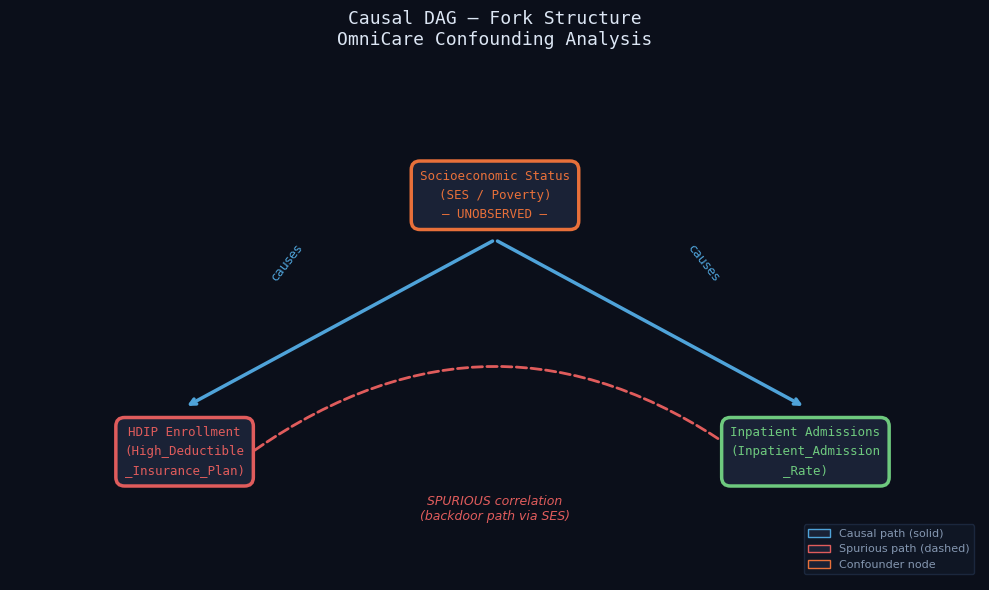

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0b0f1a')
ax.set_facecolor('#0b0f1a')
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

nodes = {
    'SES':       (5,   4.5),
    'HDIP':      (1.8, 1.5),
    'Admission': (8.2, 1.5),
}

for start, end in [('SES', 'HDIP'), ('SES', 'Admission')]:
    x1, y1 = nodes[start]
    x2, y2 = nodes[end]
    ax.annotate(
        '', xy=(x2, y2 + 0.52), xytext=(x1, y1 - 0.52),
        arrowprops=dict(
            arrowstyle='->',
            color='#4fa3d9',
            lw=2.5,
            connectionstyle='arc3,rad=0.0'
        )
    )

ax.annotate(
    '', xy=(nodes['Admission'][0] - 0.7, nodes['Admission'][1]),
    xytext=(nodes['HDIP'][0] + 0.7, nodes['HDIP'][1]),
    arrowprops=dict(
        arrowstyle='->',
        color='#e05c5c',
        lw=2,
        linestyle='dashed',
        connectionstyle='arc3,rad=-0.35'
    )
)

node_styles = {
    'SES':       dict(boxstyle='round,pad=0.7', facecolor='#1a2236', edgecolor='#e8703a', linewidth=2.5),
    'HDIP':      dict(boxstyle='round,pad=0.7', facecolor='#1a2236', edgecolor='#e05c5c', linewidth=2.5),
    'Admission': dict(boxstyle='round,pad=0.7', facecolor='#1a2236', edgecolor='#6ec97e', linewidth=2.5),
}
node_labels = {
    'SES':       'Socioeconomic Status\n(SES / Poverty)\n— UNOBSERVED —',
    'HDIP':      'HDIP Enrollment\n(High_Deductible\n_Insurance_Plan)',
    'Admission': 'Inpatient Admissions\n(Inpatient_Admission\n_Rate)',
}
node_colors = {
    'SES':       '#e8703a',
    'HDIP':      '#e05c5c',
    'Admission': '#6ec97e',
}

for key, (x, y) in nodes.items():
    ax.text(
        x, y, node_labels[key],
        ha='center', va='center',
        fontsize=9, color=node_colors[key],
        fontfamily='monospace',
        bbox=node_styles[key],
        linespacing=1.6
    )
ax.text(2.85, 3.5, 'causes', fontsize=9, color='#4fa3d9', rotation=52,  ha='center')
ax.text(7.15, 3.5, 'causes', fontsize=9, color='#4fa3d9', rotation=-52, ha='center')
ax.text(5, 0.7, 'SPURIOUS correlation\n(backdoor path via SES)',
        fontsize=9, color='#e05c5c', ha='center', style='italic')
ax.set_title(
    'Causal DAG — Fork Structure\nOmniCare Confounding Analysis',
    color='#dce6f4', fontsize=13, pad=16, fontfamily='monospace'
)

legend_elements = [
    mpatches.Patch(facecolor='#1a2236', edgecolor='#4fa3d9', label='Causal path (solid)'),
    mpatches.Patch(facecolor='#1a2236', edgecolor='#e05c5c', label='Spurious path (dashed)'),
    mpatches.Patch(facecolor='#1a2236', edgecolor='#e8703a', label='Confounder node'),
]
ax.legend(
    handles=legend_elements,
    loc='lower right',
    facecolor='#111827',
    edgecolor='#1f2d45',
    labelcolor='#8496b0',
    fontsize=8
)

plt.tight_layout();

# VIF Check

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [37]:
X = df_vitals.drop(columns=['Patient_ID']).dropna()

vif_df = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
def interpret(v):
    if v > 10:   return 'High multicollinearity'
    elif v > 5:  return 'Moderate multicollinearity'
    else:        return 'Acceptable'

vif_df['Interpretation'] = vif_df['VIF'].apply(interpret)
vif_df

,Feature,VIF,Interpretation
0,Systolic_BP,274.885624,High multicollinearity
1,Diastolic_BP,269.893182,High multicollinearity
2,Height_cm,131.175844,High multicollinearity
3,BMI,77.101031,High multicollinearity
4,Weight_kg,61.604738,High multicollinearity


BMI is a measurement that is derived from a person's height and weight, so it is redundant in this audit.

In [42]:
#dropping BMI now
X = df_vitals.drop(columns=['Patient_ID', 'BMI']).dropna()
vif_df = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
def interpret(v):
    if v > 10:   return 'High multicollinearity'
    elif v > 5:  return 'Moderate multicollinearity'
    else:        return 'Acceptable'

vif_df['Interpretation'] = vif_df['VIF'].apply(interpret)
vif_df

,Feature,VIF,Interpretation
0,Systolic_BP,270.529197,High multicollinearity
1,Diastolic_BP,267.581110,High multicollinearity
2,Height_cm,130.879345,High multicollinearity
3,Weight_kg,39.977633,High multicollinearity


In [46]:
#dropping Weight_kg and Diastolic_BP
X = df_vitals.drop(columns=['Patient_ID', 'BMI','Weight_kg','Diastolic_BP']).dropna()
vif_df = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
def interpret(v):
    if v > 10:   return 'High multicollinearity'
    elif v > 5:  return 'Moderate multicollinearity'
    else:        return 'Acceptable'

vif_df['Interpretation'] = vif_df['VIF'].apply(interpret)
vif_df

,Feature,VIF,Interpretation
0,Height_cm,43.590817,High multicollinearity
1,Systolic_BP,43.590817,High multicollinearity


# **Phase 2**